In [1]:
from google.colab import drive
drive.mount('/content/drive')

import torch
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_DIR = "/content/drive/MyDrive/GM_Assignment3_Food101"
SWIN_DIR = os.path.join(BASE_DIR, "Swin_Tiny")

folders = [
    SWIN_DIR,
    os.path.join(SWIN_DIR, "best_model"),
    os.path.join(SWIN_DIR, "checkpoints"),
    os.path.join(SWIN_DIR, "history"),
    os.path.join(SWIN_DIR, "plots"),
    os.path.join(SWIN_DIR, "results"),
    "/content/dataset"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available. Please enable GPU from Runtime > Change runtime type > T4 GPU.")

print("Swin directory:", SWIN_DIR)

Mounted at /content/drive
Device: cuda
GPU Name: Tesla T4
Swin directory: /content/drive/MyDrive/GM_Assignment3_Food101/Swin_Tiny


Download Dataset from Kaggle

In [2]:
from google.colab import files
import os, shutil

print("Please upload your kaggle.json file.")
uploaded = files.upload()

os.makedirs("/root/.kaggle", exist_ok=True)

for filename in uploaded.keys():
    if filename == "kaggle.json":
        shutil.copy(filename, "/root/.kaggle/kaggle.json")

os.chmod("/root/.kaggle/kaggle.json", 600)

print("Kaggle API key setup completed.")

!kaggle datasets download -d erika7/food-101-small-10-categories-trainvaltest-split -p /content/dataset --unzip

print("Dataset downloaded and unzipped.")

Please upload your kaggle.json file.


Saving kaggle.json to kaggle.json
Kaggle API key setup completed.
Dataset URL: https://www.kaggle.com/datasets/erika7/food-101-small-10-categories-trainvaltest-split
License(s): CC0-1.0
100% 147M/147M [00:01<00:00, 116MB/s]

Dataset downloaded and unzipped.


Dataset Paths + Count Images

In [3]:
import os

train_dir = "/content/dataset/train"
val_dir = "/content/dataset/validation"
test_dir = "/content/dataset/test"

classes = sorted(os.listdir(train_dir))
num_classes = len(classes)

print("Classes:", classes)
print("Number of classes:", num_classes)

def count_images(folder):
    total = 0
    class_counts = {}
    for cls in sorted(os.listdir(folder)):
        cls_path = os.path.join(folder, cls)
        if os.path.isdir(cls_path):
            count = len([
                f for f in os.listdir(cls_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ])
            class_counts[cls] = count
            total += count
    return total, class_counts

train_total, train_counts = count_images(train_dir)
val_total, val_counts = count_images(val_dir)
test_total, test_counts = count_images(test_dir)

print("\nTrain images:", train_total)
print("Validation images:", val_total)
print("Test images:", test_total)

print("\nTrain class counts:")
for cls, count in train_counts.items():
    print(cls, ":", count)

Classes: ['chicken_curry', 'chocolate_cake', 'fish_and_chips', 'hamburger', 'ice_cream', 'pad_thai', 'pizza', 'ramen', 'sushi', 'tacos']
Number of classes: 10

Train images: 2400
Validation images: 300
Test images: 300

Train class counts:
chicken_curry : 240
chocolate_cake : 240
fish_and_chips : 240
hamburger : 240
ice_cream : 240
pad_thai : 240
pizza : 240
ramen : 240
sushi : 240
tacos : 240


Data Transforms + DataLoaders

In [4]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

IMG_SIZE = 224
BATCH_SIZE = 16

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=eval_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=eval_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class_names = train_dataset.classes

print("Class names:", class_names)
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

images, labels = next(iter(train_loader))
print("One batch image shape:", images.shape)
print("One batch label shape:", labels.shape)

Class names: ['chicken_curry', 'chocolate_cake', 'fish_and_chips', 'hamburger', 'ice_cream', 'pad_thai', 'pizza', 'ramen', 'sushi', 'tacos']
Train batches: 150
Validation batches: 19
Test batches: 19
One batch image shape: torch.Size([16, 3, 224, 224])
One batch label shape: torch.Size([16])


Load Pretrained Swin Transformer Tiny + Replace Head

In [5]:
import torch.nn as nn
from torchvision import models

model = models.swin_t(weights=models.Swin_T_Weights.IMAGENET1K_V1)

in_features = model.head.in_features
model.head = nn.Linear(in_features, num_classes)

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model: Swin Transformer Tiny")
print("Input classes:", num_classes)
print("Final head input features:", in_features)
print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)
print("Model is on:", next(model.parameters()).device)

Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 191MB/s] 


Model: Swin Transformer Tiny
Input classes: 10
Final head input features: 768
Total parameters: 27527044
Trainable parameters: 27527044
Model is on: cuda:0


Loss Function, Optimizer, Scheduler

In [6]:
import torch.optim as optim

EPOCHS = 10
LEARNING_RATE = 1e-4

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("Loss function: CrossEntropyLoss")
print("Optimizer: AdamW")
print("Learning rate:", LEARNING_RATE)
print("Epochs:", EPOCHS)
print("Scheduler: ReduceLROnPlateau")

Loss function: CrossEntropyLoss
Optimizer: AdamW
Learning rate: 0.0001
Epochs: 10
Scheduler: ReduceLROnPlateau


Training and Validation Functions

In [7]:
import time

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / total, correct / total


def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return running_loss / total, correct / total

print("Training and validation functions are ready for Swin Tiny.")

Training and validation functions are ready for Swin Tiny.


Train Model + Save Best Model

In [8]:
import json
import os
import time
import torch

best_val_acc = 0.0
best_model_path = os.path.join(SWIN_DIR, "best_model", "swin_tiny_best.pth")
history_path = os.path.join(SWIN_DIR, "history", "swin_tiny_history.json")

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "epoch_time": []
}

total_start_time = time.time()

for epoch in range(EPOCHS):
    epoch_start_time = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    epoch_time = time.time() - epoch_start_time

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["epoch_time"].append(epoch_time)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"Best model saved at epoch {epoch+1}")

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} "
        f"Time: {epoch_time:.2f}s"
    )

total_training_time = time.time() - total_start_time

history["total_training_time"] = total_training_time
history["best_val_acc"] = best_val_acc

with open(history_path, "w") as f:
    json.dump(history, f, indent=4)

print("\nTraining completed.")
print("Best validation accuracy:", best_val_acc)
print("Total training time:", total_training_time, "seconds")
print("Best model path:", best_model_path)
print("History path:", history_path)

Best model saved at epoch 1
Epoch [1/10] Train Loss: 0.7893 | Train Acc: 0.7550 Val Loss: 0.3322 | Val Acc: 0.8933 Time: 37.55s
Best model saved at epoch 2
Epoch [2/10] Train Loss: 0.2808 | Train Acc: 0.9142 Val Loss: 0.3061 | Val Acc: 0.9100 Time: 39.78s
Best model saved at epoch 3
Epoch [3/10] Train Loss: 0.1849 | Train Acc: 0.9417 Val Loss: 0.2319 | Val Acc: 0.9267 Time: 37.96s
Epoch [4/10] Train Loss: 0.1145 | Train Acc: 0.9675 Val Loss: 0.3840 | Val Acc: 0.8967 Time: 38.73s
Epoch [5/10] Train Loss: 0.1241 | Train Acc: 0.9646 Val Loss: 0.2621 | Val Acc: 0.9267 Time: 38.40s
Epoch [6/10] Train Loss: 0.0806 | Train Acc: 0.9758 Val Loss: 0.3966 | Val Acc: 0.8933 Time: 38.93s
Best model saved at epoch 7
Epoch [7/10] Train Loss: 0.0394 | Train Acc: 0.9875 Val Loss: 0.2585 | Val Acc: 0.9333 Time: 38.58s
Best model saved at epoch 8
Epoch [8/10] Train Loss: 0.0244 | Train Acc: 0.9954 Val Loss: 0.2396 | Val Acc: 0.9400 Time: 38.62s
Best model saved at epoch 9
Epoch [9/10] Train Loss: 0.0274 

Plot Accuracy + Loss Curves

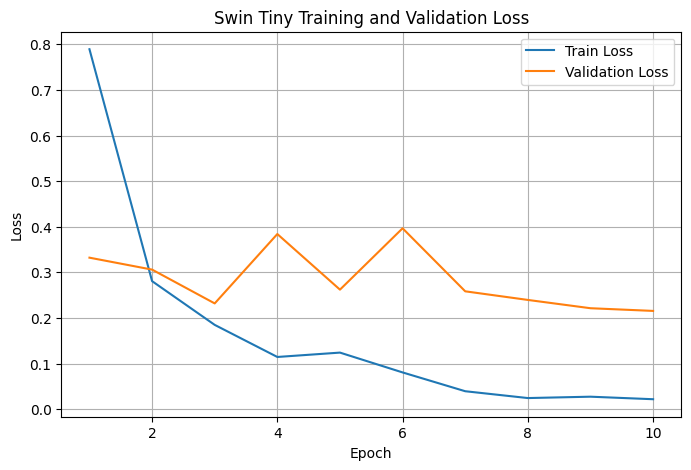

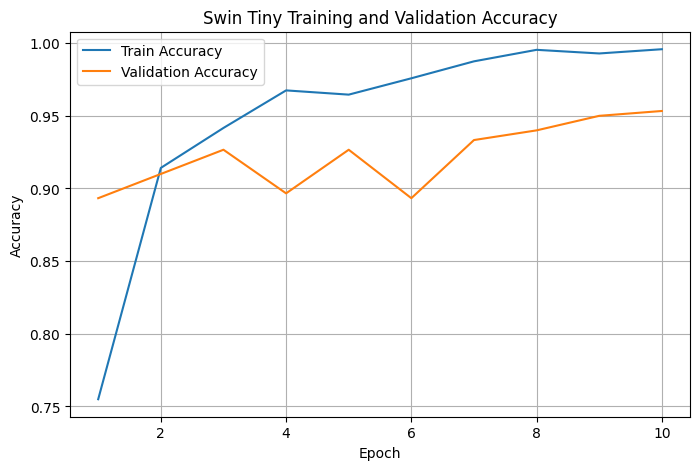

Loss curve saved at: /content/drive/MyDrive/GM_Assignment3_Food101/Swin_Tiny/plots/swin_tiny_loss_curve.png
Accuracy curve saved at: /content/drive/MyDrive/GM_Assignment3_Food101/Swin_Tiny/plots/swin_tiny_accuracy_curve.png


In [9]:
import matplotlib.pyplot as plt
import json
import os

history_path = os.path.join(SWIN_DIR, "history", "swin_tiny_history.json")

with open(history_path, "r") as f:
    history = json.load(f)

epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Swin Tiny Training and Validation Loss")
plt.legend()
plt.grid(True)

loss_plot_path = os.path.join(SWIN_DIR, "plots", "swin_tiny_loss_curve.png")
plt.savefig(loss_plot_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Swin Tiny Training and Validation Accuracy")
plt.legend()
plt.grid(True)

acc_plot_path = os.path.join(SWIN_DIR, "plots", "swin_tiny_accuracy_curve.png")
plt.savefig(acc_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Loss curve saved at:", loss_plot_path)
print("Accuracy curve saved at:", acc_plot_path)

Test Evaluation

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import torch

# Load best model
model.load_state_dict(torch.load(best_model_path))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Accuracy
test_acc = np.mean(np.array(all_preds) == np.array(all_labels))

print("Test Accuracy:", test_acc)

# Classification Report
report = classification_report(all_labels, all_preds, target_names=class_names)
print("\nClassification Report:\n")
print(report)

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:\n", cm)

Test Accuracy: 0.9266666666666666

Classification Report:

                precision    recall  f1-score   support

 chicken_curry       0.79      0.77      0.78        30
chocolate_cake       1.00      0.90      0.95        30
fish_and_chips       0.88      1.00      0.94        30
     hamburger       0.94      1.00      0.97        30
     ice_cream       0.93      0.93      0.93        30
      pad_thai       1.00      0.90      0.95        30
         pizza       0.96      0.90      0.93        30
         ramen       0.88      0.93      0.90        30
         sushi       0.97      1.00      0.98        30
         tacos       0.93      0.93      0.93        30

      accuracy                           0.93       300
     macro avg       0.93      0.93      0.93       300
  weighted avg       0.93      0.93      0.93       300


Confusion Matrix:
 [[23  0  3  0  0  0  0  3  0  1]
 [ 0 27  0  0  2  0  0  1  0  0]
 [ 0  0 30  0  0  0  0  0  0  0]
 [ 0  0  0 30  0  0  0  0  0  0]
 [

Confusion Matrix Plot

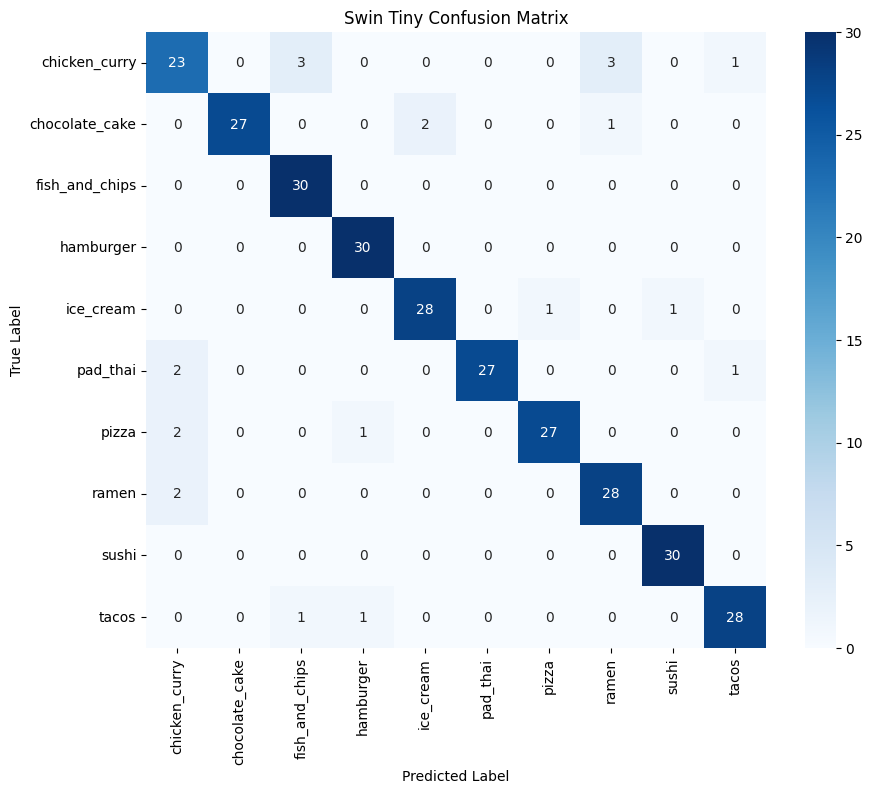

Confusion matrix plot saved at: /content/drive/MyDrive/GM_Assignment3_Food101/Swin_Tiny/plots/swin_tiny_confusion_matrix.png


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Swin Tiny Confusion Matrix")

cm_plot_path = os.path.join(SWIN_DIR, "plots", "swin_tiny_confusion_matrix.png")
plt.savefig(cm_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix plot saved at:", cm_plot_path)